# Medication order effects

PD patients were tested twice, once OFF and once ON dopaminergic medication, with the order
counterbalanced across subjects. That design invites an obvious reviewer objection to Figures 1-2:

> Your ON-medication sessions are, for some patients, also their *second* session. Is the
> medication effect on prior use actually a practice effect?

This notebook answers that objection. It asks four questions in order:

1. Is there a general practice effect, i.e. does session number alone predict prior use?
2. Does the medication effect differ by session order in the whole patient sample?
3. Does it differ by session order *within the tremor-dominant group* that carries the claim?
4. If there is an asymmetry, which subjects produce it?

Throughout, the dependent variable is the **prior effect**, `positive_bias - equal_bias`, the same
quantity plotted in the Figure 1 and Figure 2 insets.


In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
from imports import *


In [2]:
from config import dir_config
from src.utils import classification_utils
from src.utils.stats_utils import wilcoxon_battery

processed_dir = Path(dir_config.data.processed)
processed_metadata = pd.read_csv(Path(processed_dir, "processed_metadata_all_data_accu_60.csv"), index_col=None)

subjects_map, grp_indices = classification_utils.get_subject_classification_ids(processed_metadata)


PD subjects with ON+OFF sessions: 41
PD subjects with UPDRS subtype: 22
All PD subjects:           41
  Tremor dominant:         11 	 ['P3' 'P6' 'P7' 'P11' 'P12' 'P17' 'P18' 'P19' 'P29' 'P31' 'P32']
  Brady dominant:          10 	 ['P1' 'P4' 'P9' 'P13' 'P20' 'P22' 'P23' 'P28' 'P33' 'P34']
  Intermediate:            1 	 ['P24']
HC subjects:               18 	 ['HC1' 'HC3' 'HC6' 'HC7' 'HC8' 'HC9' 'HC12' 'HC13' 'AV' 'BC' 'BF' 'EM'
 'ES' 'GF' 'GP' 'JA' 'MRM' 'SY']


## Build the subject-level order table

One row per PD subject: the prior effect in each medication session, which session came first,
and the motor subtype. `off_med_first == 1` means the OFF session was session 1.


In [3]:
pd_meta = processed_metadata[processed_metadata["is_pd"] != 0].copy()
pd_meta["prior_eff"] = pd_meta["positive_bias"] - pd_meta["equal_bias"]

order = (
    pd_meta.pivot_table(index="subject_id", columns="treatment", values="prior_eff")
    .join(
        pd_meta.drop_duplicates("subject_id")
        .set_index("subject_id")[["off_med_first", "trem_vs_brady_type"]]
    )
)
order["med_effect"] = order["ON"] - order["OFF"]

# session 1 / session 2 irrespective of which drug state they were
order["session_1"] = np.where(order["off_med_first"] == 1, order["OFF"], order["ON"])
order["session_2"] = np.where(order["off_med_first"] == 1, order["ON"], order["OFF"])

print(f"PD subjects total:              {len(order)}")
print(f"  with session order recorded:  {order['off_med_first'].notna().sum()}")
print(f"    OFF session first:          {(order['off_med_first'] == 1).sum()}")
print(f"    ON session first:           {(order['off_med_first'] == 0).sum()}")
print(f"  with motor subtype:           {order['trem_vs_brady_type'].notna().sum()}")

known = order.dropna(subset=["off_med_first"]).copy()
known.head()


PD subjects total:              41
  with session order recorded:  37
    OFF session first:          22
    ON session first:           15
  with motor subtype:           22


,OFF,ON,off_med_first,trem_vs_brady_type,med_effect,session_1,session_2
subject_id,,,,,,,
ALE,0.048712,0.029475,0.0,NaN,-0.019237,0.029475,0.048712
BBK,-0.066086,0.068513,0.0,NaN,0.134598,0.068513,-0.066086
BER,0.038376,0.108398,1.0,NaN,0.070022,0.038376,0.108398
CG,-0.168831,0.348837,1.0,NaN,0.517668,-0.168831,0.348837
COH,-0.113576,0.087636,0.0,NaN,0.201213,0.087636,-0.113576


## Q1. Is there a general practice effect?

The cleanest version of the objection ignores medication entirely: if patients simply get better at
reading the colour cue the second time they sit the task, session 2 should show a larger prior
effect than session 1 regardless of drug state.


In [4]:
practice = wilcoxon_battery(
    tests={"session 1 vs session 2": (known["session_1"], known["session_2"])},
    correction="bonferroni",
    label="Practice effect, medication ignored",
)

print(f"\n  session 1 mean = {known['session_1'].mean():+.4f}")
print(f"  session 2 mean = {known['session_2'].mean():+.4f}")


Group: Practice effect, medication ignored
  session 1 vs session 2: p = 0.386, corrected p = 0.386, cohen_d = 0.14, power = 0.13  (n=37)


  session 1 mean = +0.0640
  session 2 mean = +0.0309


**Result.** Session number alone does not predict prior use. Patients are, if anything, marginally
*worse* in session 2, which is the opposite direction to a practice account. The mechanism a
reviewer would propose is not present in the data.


## Q2. Does the medication effect depend on order, in the whole sample?

Split the patients by which session came first and look at the prior effect in each drug state
separately. Each cell gets a one-sample Wilcoxon against zero, which is the Figure 1 test run
within an order subgroup.


In [5]:
rows = []
for flag, label in [(1.0, "OFF session first"), (0.0, "ON session first")]:
    g = known[known["off_med_first"] == flag]
    res = wilcoxon_battery(
        tests={"OFF session": (g["OFF"],), "ON session": (g["ON"],)},
        print_results=False,
    ).set_index("test")
    rows.append({
        "order": label,
        "n": len(g),
        "prior effect OFF": g["OFF"].mean(),
        "p (OFF vs 0)": res.loc["OFF session", "p"],
        "prior effect ON": g["ON"].mean(),
        "p (ON vs 0)": res.loc["ON session", "p"],
        "medication effect": g["med_effect"].mean(),
    })

whole_sample = pd.DataFrame(rows).set_index("order")
whole_sample.round(4)


,n,prior effect OFF,p (OFF vs 0),prior effect ON,p (ON vs 0),medication effect
order,,,,,,
OFF session first,22,0.0355,0.4628,0.0403,0.3880,0.0049
ON session first,15,0.0172,0.8904,0.1058,0.0015,0.0886


Read naively, this table is the problem: the ON-medication prior effect is significant only among
the patients whose ON session came first. But comparing two subgroup p-values is not a test of
whether the subgroups differ. The correct test is the **order x medication interaction**, i.e. a
between-subjects comparison of each patient's own OFF-to-ON change.


In [6]:
a = known.loc[known["off_med_first"] == 1, "med_effect"]
b = known.loc[known["off_med_first"] == 0, "med_effect"]
u, p_int = stats.mannwhitneyu(a, b)

print("Order x medication interaction, all PD")
print(f"  OFF-first medication effect: {a.mean():+.4f}  (n={len(a)})")
print(f"  ON-first  medication effect: {b.mean():+.4f}  (n={len(b)})")
print(f"  Mann-Whitney U = {u:.1f}, p = {p_int:.4f}")


Order x medication interaction, all PD
  OFF-first medication effect: +0.0049  (n=22)
  ON-first  medication effect: +0.0886  (n=15)
  Mann-Whitney U = 128.0, p = 0.2589


**Result.** The interaction is not significant. The apparent order dependence in the table above is
a difference in significance, not a significant difference, which is what splitting a marginal
effect into two underpowered halves reliably produces.


## Q3. The group that carries the claim

Figures 2 through 4 rest on the tremor-dominant group, not on all patients. Run the same split there.


In [7]:
subtype_rows = []
for subtype in ["tremor", "bradykinetic"]:
    g = known[known["trem_vs_brady_type"] == subtype]
    for flag, label in [(1.0, "OFF first"), (0.0, "ON first")]:
        s = g[g["off_med_first"] == flag]
        subtype_rows.append({
            "subtype": subtype,
            "order": label,
            "n": len(s),
            "bias OFF": s["OFF"].mean(),
            "bias ON": s["ON"].mean(),
            "medication effect": s["med_effect"].mean(),
        })

by_subtype = pd.DataFrame(subtype_rows).set_index(["subtype", "order"])
display(by_subtype.round(4))

print("\nOrder x medication interaction, within subtype")
for subtype in ["tremor", "bradykinetic"]:
    g = known[known["trem_vs_brady_type"] == subtype]
    a = g.loc[g["off_med_first"] == 1, "med_effect"]
    b = g.loc[g["off_med_first"] == 0, "med_effect"]
    u, p = stats.mannwhitneyu(a, b)
    print(f"  {subtype:13s} U = {u:5.1f}, p = {p:.4f}   (n = {len(a)} OFF-first, {len(b)} ON-first)")


n  bias OFF  bias ON  medication effect
subtype      order                                             
tremor       OFF first  6    0.0111   0.1026             0.0916
             ON first   5   -0.0118   0.1245             0.1363
bradykinetic OFF first  6    0.0352   0.0355             0.0003
             ON first   4    0.1189   0.0653            -0.0536


Order x medication interaction, within subtype
  tremor        U =  14.0, p = 0.9307   (n = 6 OFF-first, 5 ON-first)
  bradykinetic  U =  12.0, p = 1.0000   (n = 6 OFF-first, 4 ON-first)


With 5 and 6 subjects per cell the Mann-Whitney test has very little power, so a null there is weak
evidence on its own. A permutation test on the same contrast is the honest supplement: shuffle the
order labels within the subtype and ask how often the observed difference in medication effect is
exceeded.


In [8]:
rng = np.random.default_rng(0)
N_PERM = 10_000

print(f"Permutation test on the order x medication interaction ({N_PERM:,} shuffles)")
for subtype in ["tremor", "bradykinetic"]:
    g = known[known["trem_vs_brady_type"] == subtype]
    eff = g["med_effect"].to_numpy()
    lab = (g["off_med_first"] == 1).to_numpy()
    observed = eff[lab].mean() - eff[~lab].mean()
    null = np.empty(N_PERM)
    for i in range(N_PERM):
        shuffled = rng.permutation(lab)
        null[i] = eff[shuffled].mean() - eff[~shuffled].mean()
    p_perm = (np.abs(null) >= np.abs(observed)).mean()
    print(f"  {subtype:13s} observed difference = {observed:+.4f}, permutation p = {p_perm:.4f}")


Permutation test on the order x medication interaction (10,000 shuffles)
  tremor        observed difference = -0.0447, permutation p = 0.7491
  bradykinetic  observed difference = +0.0538, permutation p = 0.7246


**Result.** In the tremor-dominant group the medication effect is present and similar in size under
both orders. Neither the rank test nor the permutation test finds an order dependence. The claim in
Figures 2 through 4 is order-robust.


## Q4. Where does the whole-sample asymmetry come from?

It is tempting to attribute it to the 19 patients who lack item-level MDS-UPDRS ratings and
therefore have no subtype, since they contribute to Figure 1 only. That turns out to be too clean.


In [9]:
origin_rows = []
for label, mask in [
    ("subtyped (Figs 2-4)", known["trem_vs_brady_type"].notna()),
    ("unclassified (Fig 1 only)", known["trem_vs_brady_type"].isna()),
]:
    g = known[mask]
    a = g.loc[g["off_med_first"] == 1, "med_effect"]
    b = g.loc[g["off_med_first"] == 0, "med_effect"]
    origin_rows.append({
        "subjects": label,
        "n": len(g),
        "OFF-first effect": a.mean(),
        "n OFF-first": len(a),
        "ON-first effect": b.mean(),
        "n ON-first": len(b),
        "asymmetry": b.mean() - a.mean(),
    })

pd.DataFrame(origin_rows).set_index("subjects").round(4)


,n,OFF-first effect,n OFF-first,ON-first effect,n ON-first,asymmetry
subjects,,,,,,
subtyped (Figs 2-4),22,0.0012,13,0.0519,9,0.0507
unclassified (Fig 1 only),15,0.0102,9,0.1436,6,0.1334


**Result.** The unclassified patients show the larger asymmetry, but the subtyped patients show a
smaller one too. The asymmetry is diluted rather than absent in the subtyped group, and it only
disappears once tremor is separated from bradykinesia. So the defence is the null interaction and
the absent practice effect, **not** attribution to one subgroup.


## Figure

Two panels: the whole patient sample split by order, and the tremor-dominant group split by order.


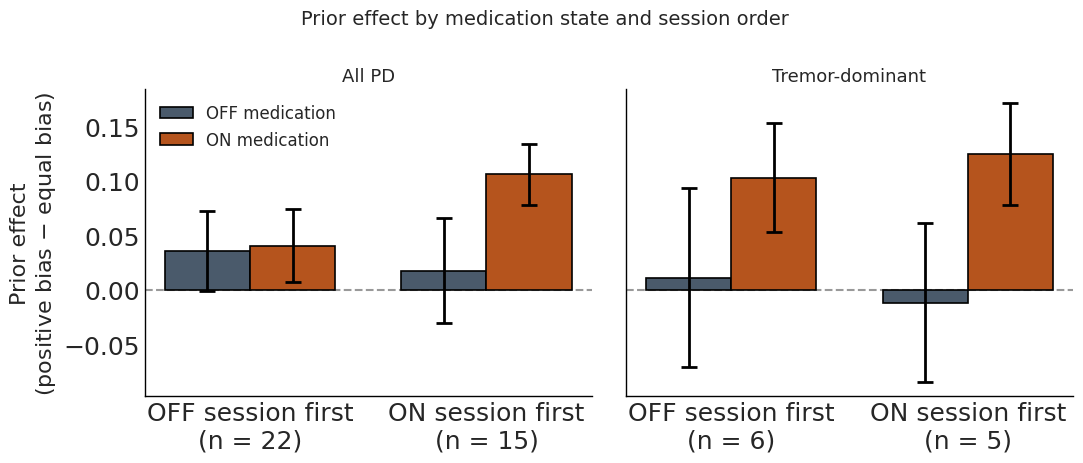

In [10]:
off_color, on_color = "#4A5A6B", "#B5541D"
err_style = {"elinewidth": 2, "capsize": 6, "capthick": 2}

panels = [
    ("All PD", known),
    ("Tremor-dominant", known[known["trem_vs_brady_type"] == "tremor"]),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

for ax, (title, g) in zip(axes, panels):
    x = np.arange(2)
    width = 0.36
    for offset, drug, color in [(-width / 2, "OFF", off_color), (width / 2, "ON", on_color)]:
        means, sems = [], []
        for flag in (1.0, 0.0):
            vals = g.loc[g["off_med_first"] == flag, drug]
            means.append(vals.mean())
            sems.append(stats.sem(vals))
        ax.bar(x + offset, means, width, color=color, edgecolor="k", lw=1.2, label=f"{drug} medication")
        ax.errorbar(x + offset, means, yerr=sems, color="k", ls="", **err_style)

    labels = []
    for flag, name in [(1.0, "OFF session first"), (0.0, "ON session first")]:
        n = (g["off_med_first"] == flag).sum()
        labels.append(f"{name}\n(n = {n})")

    ax.axhline(0, color="0.6", ls="--", lw=1.5, zorder=0)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(title, fontsize=13)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Prior effect\n(positive bias $-$ equal bias)")
axes[0].legend(frameon=False, loc="upper left")
fig.suptitle("Prior effect by medication state and session order", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


## Summary

| Question | Answer |
|---|---|
| General practice effect? | No. Session 1 vs session 2, medication ignored, is null and points the wrong way. |
| Order x medication interaction, all PD? | Not significant. |
| Order x medication interaction, tremor-dominant? | Not significant, by rank test or permutation. Effect present in both orders. |
| Source of the whole-sample asymmetry? | Diluted across both subtyped and unclassified patients. Not attributable to one subgroup. |

**Suggested supplementary text.**

> Because medication order was counterbalanced, we verified that the medication effect on prior use
> was not a practice effect. Ignoring medication state, prior use did not differ between the first
> and second session. The order x medication interaction was not significant in the full patient
> sample, nor within the tremor-dominant group, where the medication effect was of comparable
> magnitude in patients tested OFF first and ON first (Supplementary Table S#).

**Caveat to keep.** The all-patients ON-medication result in Figure 1e is corrected p = 0.023 and
does not reach significance on its own within the larger (OFF-first) order subgroup. That is
expected for a marginal effect split in half, but it should be reported transparently rather than
claimed away.
